In [5]:
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import corner

In [2]:
ds = xr.open_dataset("../data/chain_0.5.nc")
var = next(iter(ds.data_vars))
arr = ds[var].values

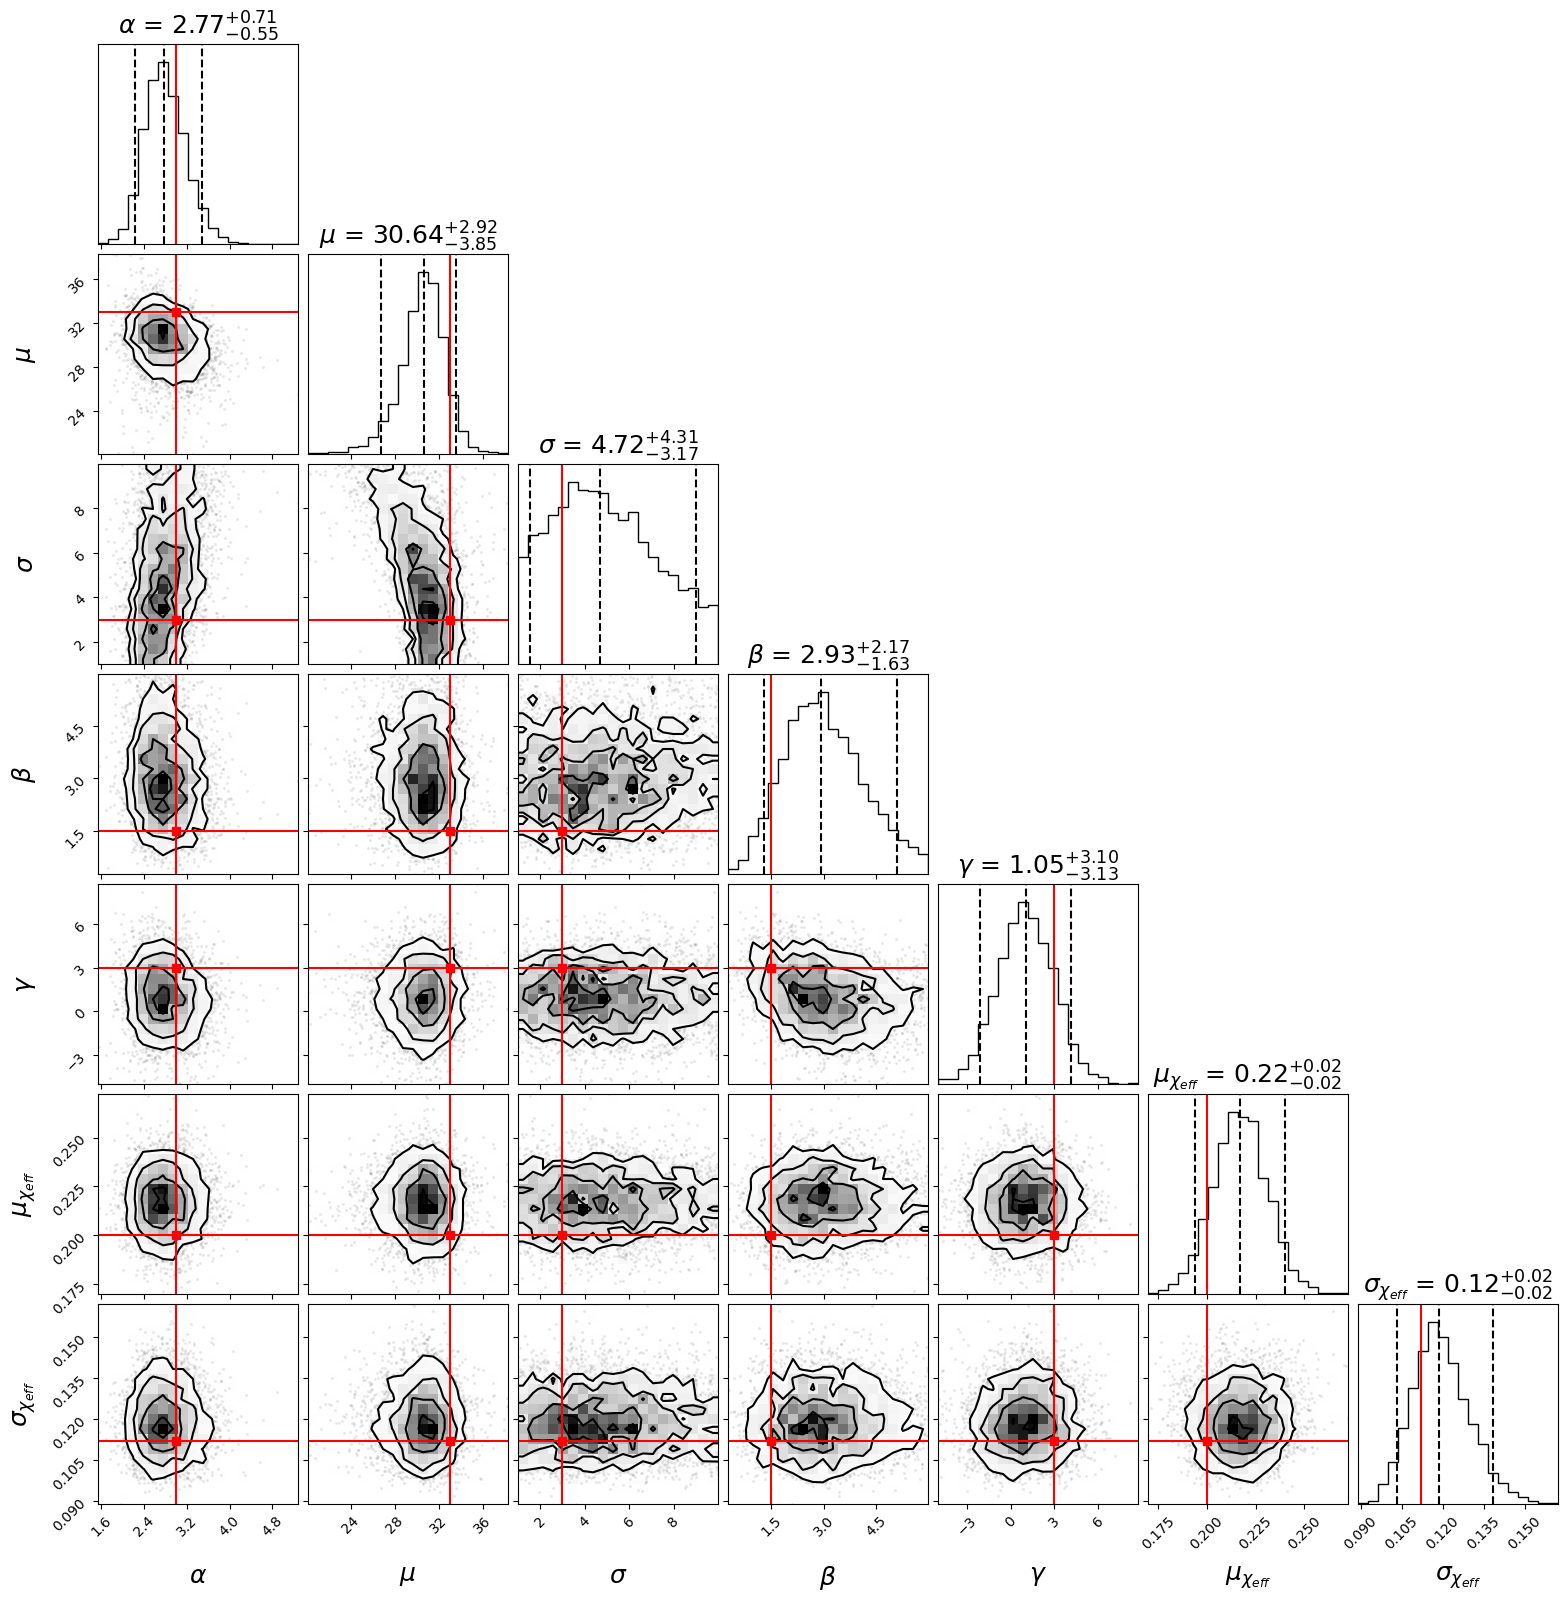

In [9]:
labels = [r'$\alpha$',r'$\mu$',r'$\sigma$',r'$\beta$',r'$\gamma$',r'$\mu_{\chi_{eff}}$',r'$\sigma_{\chi_{eff}}$']

true = np.array([3.0, 33.0, 3.0, 1.5, 3.0, 0.2, 10.**(-0.95)])
figure = corner.corner(
    arr.T,
    labels=labels,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_kwargs={"fontsize": 18},
    label_kwargs={"fontsize": 18},
)

# Extract the axes
axes = np.array(figure.axes).reshape((len(true), len(true)))

# Loop over the diagonal
for i in range(len(true)):
    ax = axes[i, i]
    ax.axvline(true[i], color="r")



# Loop over the histograms
for yi in range(len(true)):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axvline(true[xi], color="r")
        ax.axhline(true[yi], color="r")
        ax.plot(true[xi], true[yi], "sr")

figure.savefig("../figures/appen_D_corner_plot.pdf", bbox_inches="tight")